In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### **As the Dataset was clean already and separated in dogs and cats, We can proceed with train test split**

In [2]:
import os
import random
import shutil

# Aim here is to segregate the data into training set folder (containing training images) 
# and test set folder (containing test images)

def train_test_split_folder(source_folder, train_folder, test_folder, split_ratio=0.8):
    # Ensure train and test root directories exist
    if not os.path.exists(train_folder):
        os.makedirs(train_folder)
    if not os.path.exists(test_folder):
        os.makedirs(test_folder)

    for class_name in os.listdir(source_folder):
        class_source_path = os.path.join(source_folder, class_name)

        if os.path.isdir(class_source_path):  # Check if it is a directory (e.g., 'dog', 'cat')
            train_class_path = os.path.join(train_folder, class_name)
            test_class_path = os.path.join(test_folder, class_name)

            # Create class folders (e.g., 'data/train/dog')
            if not os.path.exists(train_class_path):
                os.makedirs(train_class_path)
            if not os.path.exists(test_class_path):
                os.makedirs(test_class_path)

            # Get list of all images in class folder
            images = [f for f in os.listdir(class_source_path) if os.path.isfile(os.path.join(class_source_path, f))]
            
            # Shuffle and split
            random.shuffle(images)
            split_index = int(len(images) * split_ratio)
            train_images = images[:split_index]
            test_images = images[split_index:]

            # Copy files to designated folders
            for image in train_images:
                source_path = os.path.join(class_source_path, image)
                destination_path = os.path.join(train_class_path, image)
                shutil.copy(source_path, destination_path)

            for image in test_images:
                source_path = os.path.join(class_source_path, image)
                destination_path = os.path.join(test_class_path, image)
                shutil.copy(source_path, destination_path)

# Example usage:
# Using '../' ensures folders are created in the project root, outside the 'notebook' folder
train_test_split_folder(
    source_folder="../dataset", 
    train_folder="../data/train", 
    test_folder="../data/test",
    split_ratio=0.8
)

### **Count no of images**

In [3]:
import os

def count_images_per_folder(root_folder):
  """
  Counts the number of images in each subfolder of a given root folder.

  Args:
    root_folder: The path to the root folder.

  Returns:
    A dictionary where keys are folder paths and values are the number of images in each folder.
  """

  image_counts = {}
  for dirpath, dirnames, filenames in os.walk(root_folder):
    image_count = 0
    for filename in filenames:
      if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
        image_count += 1
    if image_count > 0 :
      image_counts[dirpath] = image_count
  return image_counts

# Example usage
image_counts = count_images_per_folder("../data")
for folder, count in image_counts.items():
    print(f"Folder: {folder}, Number of images: {count}")

Folder: ../data\test\cats_set, Number of images: 301
Folder: ../data\test\dogs_set, Number of images: 297
Folder: ../data\train\cats_set, Number of images: 500
Folder: ../data\train\dogs_set, Number of images: 500


## **Import all necessary MODULES**

In [4]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1' 

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

In [5]:
# Set paths to train and test folders
train_dir = "../data/train"
test_dir = "../data/test"
image_size = (128, 128)
batch_size = 32

### **Data Preparation**

In [6]:
'''
Instead of loading thousands of images into your RAM all at once (which would crash most computers), these generators create a stream. When the model asks for data, the generator:

- Grabs a batch of images from the disk.
- Resizes them.
- Rescales the pixels.
- Passes them to the GPU.
- Deletes them from RAM and grabs the next batch.
'''
# Data Augmentation by flipping the same image and creating multiple variations because dataset is only 1000 images model was overfitting (yes I ran 10 epochs initially)
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,      # Rotate images
    width_shift_range=0.2,  # Shift horizontally
    height_shift_range=0.2, # Shift vertically
    shear_range=0.2,        # Shear transformations
    zoom_range=0.2,         # Zoom in/out
    horizontal_flip=True,   # Flip images
    fill_mode='nearest',
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

test_data = datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 800 images belonging to 2 classes.
Found 119 images belonging to 2 classes.


## **Model Architecture - CNN**

In [7]:
#added BatchNormalization after I saw the model was Overfitting
from tensorflow.keras.layers import BatchNormalization
model = Sequential([
    #Input Layer
    Conv2D(32, (3, 3), activation='relu', input_shape = (128, 128, 3)),
    # Add BatchNormalization() layers after your Conv2D layers. This stabilizes the learning process and often allows the model to converge to a higher accuracy.
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # binary classification
])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 126, 126, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 61, 61, 64)       256       
 hNormalization)                                                 
                                                        

## **Model Compilation and Training**

In [8]:
model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])

# Training the Model
checkpoint_path = '..model/dog_cat_cnn_model.keras'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)

# Capture the training history
history = model.fit(
    train_data,
    epochs=50,
    validation_data=test_data,
    callbacks=[checkpoint]
)

Epoch 1/50
25/25 [==============================] - 12s 151ms/step - loss: 1.1916 - accuracy: 0.5362 - val_loss: 0.9020 - val_accuracy: 0.5042
Epoch 2/50
25/25 [==============================] - 4s 160ms/step - loss: 0.8013 - accuracy: 0.5888 - val_loss: 1.5695 - val_accuracy: 0.5042
Epoch 3/50
25/25 [==============================] - 3s 120ms/step - loss: 0.6803 - accuracy: 0.6288 - val_loss: 1.7093 - val_accuracy: 0.5042
Epoch 4/50
25/25 [==============================] - 3s 108ms/step - loss: 0.6811 - accuracy: 0.6000 - val_loss: 1.6676 - val_accuracy: 0.5042
Epoch 5/50
25/25 [==============================] - 3s 103ms/step - loss: 0.6417 - accuracy: 0.6275 - val_loss: 2.2926 - val_accuracy: 0.5042
Epoch 6/50
25/25 [==============================] - 2s 98ms/step - loss: 0.6314 - accuracy: 0.6438 - val_loss: 1.9962 - val_accuracy: 0.5042
Epoch 7/50
25/25 [==============================] - 3s 102ms/step - loss: 0.6139 - accuracy: 0.6550 - val_loss: 3.2031 - val_accuracy: 0.5042
Epoch 

## **Loss Curve**

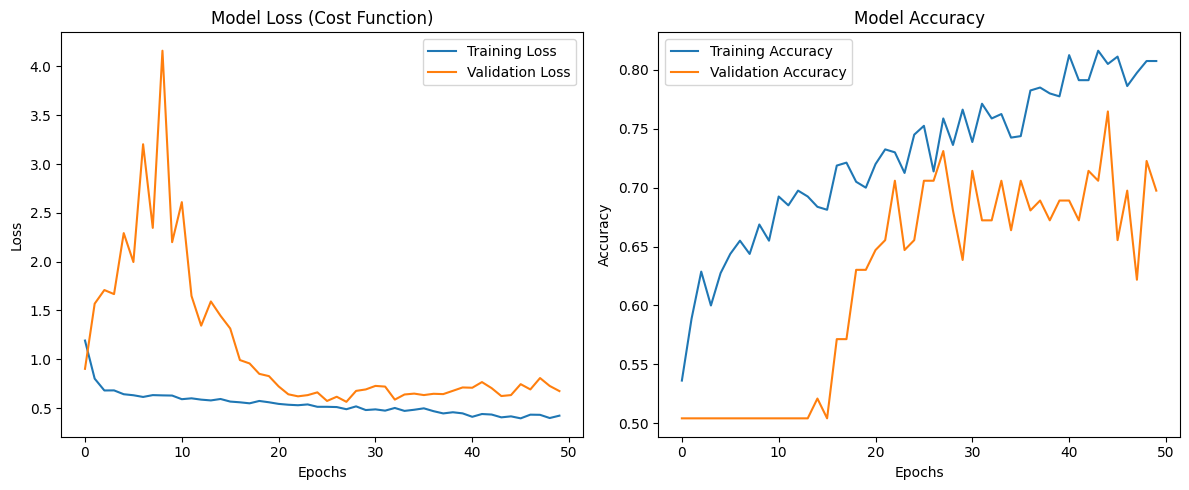

In [9]:
import matplotlib.pyplot as plt

# Create a figure with two subplots: Loss and Accuracy
plt.figure(figsize=(12, 5))

# Plot Training & Validation Loss (Cost Function)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Cost Function)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## **Save the Model**

In [12]:
# Save final model
model.save('../model/dog_cat_cnn_model.keras')

### **Load The Model**

In [14]:
from tensorflow.keras.models import load_model

# Load the best saved model
model = load_model('../model/dog_cat_cnn_model.keras')

## **Model Evaluation**

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set parameters
val_dir = test_dir  # same directory used for training
image_size = (128, 128)
batch_size = 32

# Recreate the validation generator
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.25)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

# Evaluate model accuracy
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

Found 149 images belonging to 2 classes.


5/5 [==============================] - 1s 91ms/step - loss: 0.5318 - accuracy: 0.8054
Validation Accuracy: 80.54%


In [ ]:
#TRUE accuracy -  evaluating the model on every single image in test folder without splitting it.

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Load the model from the notebook folder (where it currently is)
model = load_model('dog_cat_cnn_model.keras')

# 2. Create a simple generator WITHOUT any splits
test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Point it at your test directory
true_test_generator = test_datagen.flow_from_directory(
    "../data/test",
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False # Keep it false for evaluation
)

# 4. Evaluate
loss, accuracy = model.evaluate(true_test_generator)
print(f"True Accuracy on ALL Test Images: {accuracy * 100:.2f}%")

Found 357 images belonging to 2 classes.
12/12 [==============================] - 1s 44ms/step - loss: 0.5339 - accuracy: 0.7535
True Accuracy on ALL Test Images: 75.35%


## **Model Inferencing**

In [16]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(img_path, model):
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        print("Predicted: Dog")
    else:
        print("Predicted: Cat")

### Inference of a CAT

In [17]:
predict_image("../data/test/cats_set/cat.4005.jpg", model)

1/1 [==============================] - 0s 422ms/step
Predicted: Cat


### Inference of a DOG

In [18]:
predict_image("../data/test/dogs_set/dog.4017.jpg", model)

1/1 [==============================] - 0s 16ms/step
Predicted: Dog
